# Notebook 02 : Feature Engineering & Rétro-Ingénierie

**Contexte & Objectif :** Suite à notre audit initial ayant prouvé l'incompatibilité structurelle de nos deux sources de données, nous devons adopter une stratégie de modélisation avancée. Pour modéliser les rendements agricoles (données FAO) avec une grande précision, ce notebook implémente une **Architecture Hybride de type "Coupling"**, directement inspirée des travaux de recherche de **Shahhosseini et al. (2021)**.

**La méthode scientifique :** L'approche de Shahhosseini repose sur deux piliers agronomiques que nous allons reproduire ici :
1. **L'isolation du progrès technologique :** La capacité à extraire une tendance d'amélioration des rendements au fil du temps (`yield_trend`).
2. **La génération d'indicateurs biophysiques :** L'utilisation d'un modèle intermédiaire (le "Teacher") pour transformer la météo brute en probabilités de stress (Thermique et Hydrique), qui deviendront les *features* expertes de notre modèle final (le "Student").

**Plan d'Action :**

1. **Pré-traitement Temporel :** L'extraction du `yield_trend` exigeant des séries historiques continues, nous forgerons d'abord un "Golden Dataset" (Audit temporel et Gap Filling).
2. **Modélisation Agronomique (FAO) :** Calcul de l'Indice d'Aridité de De Martonne, puis entraînement de notre modèle "Teacher" pour générer nos indicateurs de stress.
3. **Rétro-Ingénierie (Règles Métier) :** Nous appliquerons une Régression Linéaire (GLM) sur le simulateur historique factice pour extraire mathématiquement ses poids (`.coef_`). Ils constitueront notre moteur de règles (Bonus/Malus).
4. **Génération des Livrables (MLOps) :** Export du dataset d'entraînement "Student" et des règles métier pour l'application Streamlit.

## Imports et chargements des datasets 

In [1]:
## Imports et configuration
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import time
import os

# Visuels
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# === CONFIGURATION PROJET ===
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# === SKLEARN - PREPROCESSING ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# === SKLEARN - MODÈLES ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# === SKLEARN - MÉTRIQUES ===
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Sauegardes
import json

# Chemins
from config.paths import DONNEES_PROCESSED
from config.config import RANDOM_STATE

In [2]:
df_fao_consolidated = pd.read_csv(DONNEES_PROCESSED / "df_fao_consolidated.csv")
df_dummy_synthetique = pd.read_csv(DONNEES_PROCESSED / "dummy_synthetique.csv")

In [3]:
df_fao_consolidated['Item'].value_counts()

Item
Maize      1983
Wheat      1805
Rice       1502
Soybean    1242
Name: count, dtype: int64

## Pré-traitement temporel
**Contexte :** Comme annoncé dans notre stratégie, l'architecture de Shahhosseini repose sur l'apprentissage d'une tendance technologique (`yield_trend`). Mathématiquement, le calcul d'une telle tendance ne tolère ni les séries temporelles trop courtes, ni les "trous" au milieu des années. 

**Objectifs de cette section :**
* **Audit Temporel :** Évaluer la continuité des données (Matrice de disponibilité) et la profondeur historique de chaque culture (Span).
* **Gap Filling :** Combler les valeurs manquantes isolées (1 à 2 ans) par interpolation linéaire géométrique pour préserver la variance de nos séries.
* **Définition du "Golden Dataset" :** Appliquer un seuil de coupure strict pour exclure les pays ayant un historique insuffisant, garantissant ainsi un apprentissage fiable au modèle.

### Audit et Filtrage
Nous allons exclure les pays avec une profondeur historique insuffisante (le span). En effet, un modèle ne peut pas apprendre une tendance cliamatique sur 4 années de données

#### Matrice de disponibilité

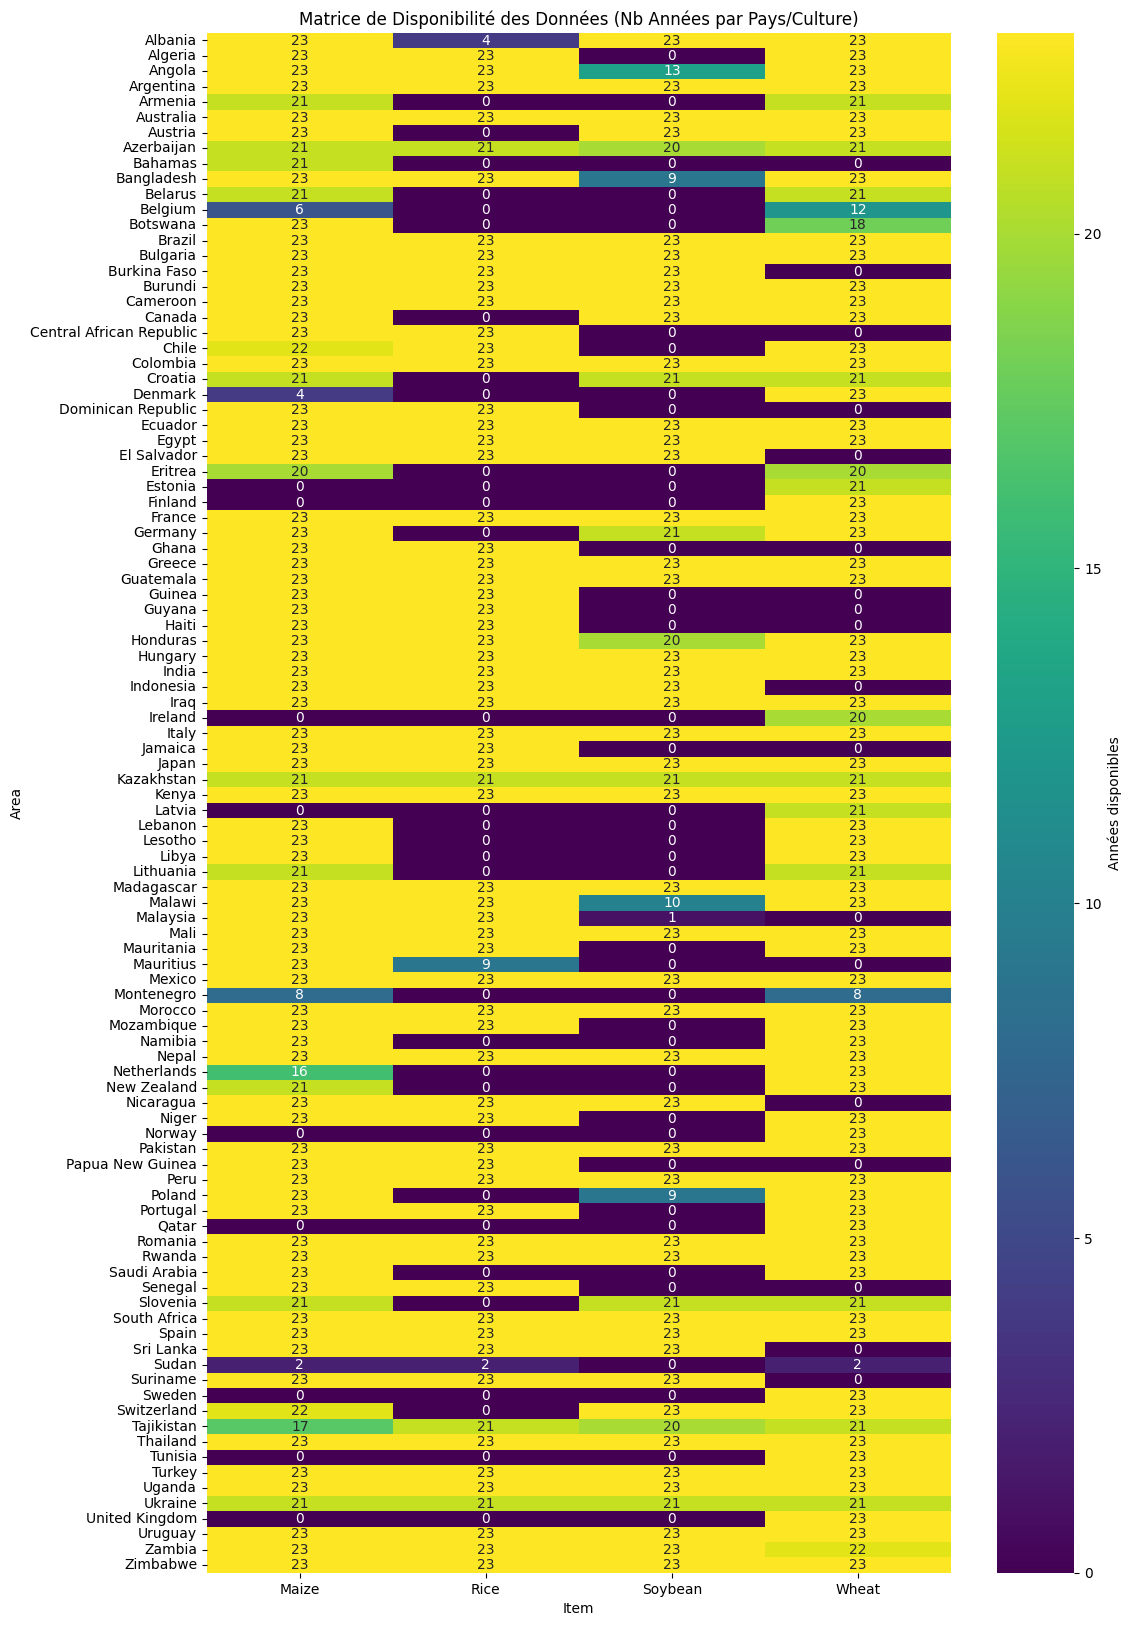

In [4]:
# Création pivot table
df_pivot_fao = pd.pivot_table(df_fao_consolidated, values='Year', index='Area', columns=['Item'], aggfunc='count').fillna(0)

# Visualisation (Heatmap)
plt.figure(figsize=(12, 20)) # Grande hauteur car beaucoup de pays
sns.heatmap(df_pivot_fao, annot=True, fmt='g', cmap='viridis', cbar_kws={'label': 'Années disponibles'})
plt.title('Matrice de Disponibilité des Données (Nb Années par Pays/Culture)')
plt.show()

**Diagnostic Visuel :**
Cette heatmap révèle la structure "trouée" (Sparse Data) de notre jeu de données.

1.  **Spécialisation Agronomique :**
    * Les "trous" ne sont pas forcément des données manquantes, mais souvent une **réalité agronomique** (ex: La Suède ne cultive pas de Riz, l'Égypte ne cultive pas de Soja sans irrigation intensive).
    * Il est inutile de vouloir forcer le modèle à prédire ces cases vides.

2.  **Disparité de Profondeur :**
    * Certains pays (ex: USA, France, Brésil) sont des "bons élèves" avec des séries complètes (~25-30 ans).
    * D'autres (ex: Albanie, petits pays) n'ont que des fragments d'historique (< 10 ans).

**Décision Stratégique (Golden Dataset) :**
Pour l'architecture Shahhosseini (qui nécessite d'apprendre une tendance `Yield_Trend`), nous ne pouvons pas conserver les séries trop courtes.
> **Action à suivre :** Nous allons calculer le "Span" (Durée de vie) de chaque série et appliquer un seuil de coupure (Thresholding) pour ne garder que les couples Pays/Culture robustes.

#### Analyse du span (durée de vie)

Aperçu des séries courtes (Span < 10 ans) :
                     min   max  span_years
Area       Item                           
Albania    Rice     1990  1993           3
Bangladesh Soybean  2005  2013           8
Denmark    Maize    2010  2013           3
Malawi     Soybean  2004  2013           9
Malaysia   Soybean  1990  1990           0


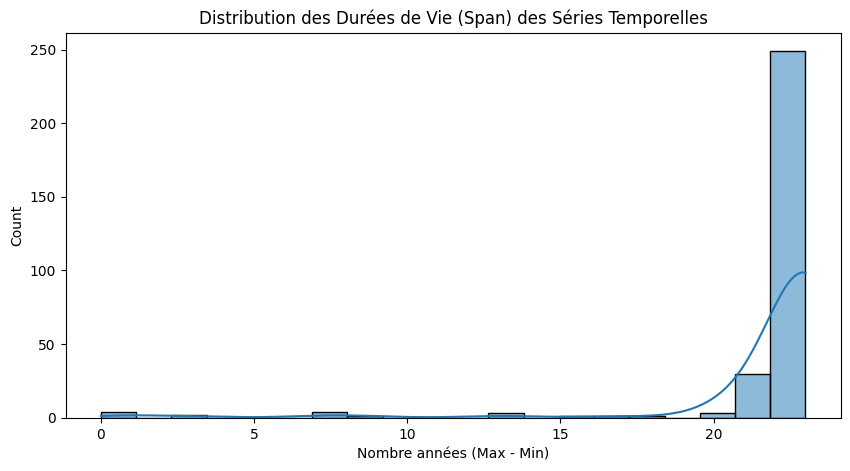

In [5]:
# 1. On groupe et on récupère Min/Max
# Correction : crochets simples pour la liste des colonnes
df_span = df_fao_consolidated.groupby(['Area', 'Item'])['Year'].agg(['min', 'max'])

# 2. On calcule la soustraction (La durée de vie)
# On ajoute une nouvelle colonne 'span_years'
df_span['span_years'] = df_span['max'] - df_span['min']

# 3. Visualisation des "mauvais élèves" (ceux qui ont moins de 10 ans de span)
print("Aperçu des séries courtes (Span < 10 ans) :")
print(df_span[df_span['span_years'] < 10].head())

# 4. Visualisation de la distribution (Exercice demandé)
plt.figure(figsize=(10, 5))
sns.histplot(df_span['span_years'], bins=20, kde=True)
plt.title('Distribution des Durées de Vie (Span) des Séries Temporelles')
plt.xlabel('Nombre années (Max - Min)')
plt.show()

La grande majorité des couples (Pays + Culture) ont des données qui couvrent toute la période (1990-2013).

Conséquence technique : Cela signifie qu'on pourra calculer un yield_trend (la pente du progrès technologique) fiable.

### Continuité et Gap Filling
Interpolation linéaire des trous (1 à 2 ans).

In [6]:
# 1. Pivot : On met les années en colonnes pour aligner le temps
# Cela crée une grille où les trous apparaissent comme NaN
df_pivot_col_annee = df_fao_consolidated.pivot_table(
    index=['Area', 'Item'],
    columns='Year',
    values='yield_hg_per_ha'
)

In [7]:
df_pivot_col_annee.head()

Year                1990     1991     1992     1993     1994     1995  \
Area    Item                                                            
Albania Maize    36613.0  29068.0  24876.0  24185.0  25848.0  31300.0   
        Rice     23333.0  28538.0  40000.0  41786.0      NaN      NaN   
        Soybean   7000.0   6066.0   4507.0   7998.0   7927.0  11791.0   
        Wheat    30197.0  20698.0  24388.0  29976.0  24745.0  28703.0   
Algeria Maize    16500.0  19231.0  22828.0  12500.0   4512.0  16115.0   

Year                1996     1997     1998     1999  ...     2004     2005  \
Area    Item                                         ...                     
Albania Maize    32604.0  31862.0  33416.0  37455.0  ...  46197.0  45442.0   
        Rice         NaN      NaN      NaN      NaN  ...      NaN      NaN   
        Soybean  15480.0  12768.0  14327.0  17143.0  ...  13333.0  17500.0   
        Wheat    21741.0  28516.0  28037.0  24954.0  ...  31130.0  31582.0   
Algeria Maize    17154.0  21417.0  17222.0  22375.0  ...  31729.0  33864.0   

Year                2006     2007     2008     2009     2010     2011  \
Area    Item                                                            
Albania Maize    50111.0  46732.0  50000.0  55693.0  66790.0  59869.0   
        Rice         NaN      NaN      NaN      NaN      NaN      NaN   
        Soybean  20000.0  20000.0  20000.0  16667.0  16667.0  18519.0   
        Wheat    30787.0  35496.0  40168.0  40229.0  39905.0  42301.0   
Algeria Maize    65668.0  85625.0  44714.0  30914.0  25827.0  23374.0   

Year                2012     2013  
Area    Item                       
Albania Maize    67290.0  69533.0  
        Rice         NaN      NaN  
        Soybean  13333.0  10000.0  
        Wheat    41096.0  41292.0  
Algeria Maize    25583.0  33649.0  

[5 rows x 23 columns]

In [8]:
# 2. Interpolation
# limit=2 : On ne comble pas si le trou fait plus de 2 ans
# limit_area='inside' : CRITIQUE. On ne comble que les trous AU MILIEU.
# On n'invente pas de données avant la première année ni après la dernière.
df_interpolated = df_pivot_col_annee.interpolate(method='linear', axis=1, limit=2, limit_area='inside')

# 3. Retour au format Long (Melt)
df_filled = df_interpolated.reset_index().melt(
    id_vars=['Area', 'Item'],
    var_name='Year',
    value_name='yield_hg_per_ha'
)

In [9]:
print(f"Taille avant suppression des rendements vides {df_filled.shape}")

# 4. Nettoyage : On retire les lignes qui sont restées vides (les bouts non interpolés)
df_filled = df_filled.dropna(subset=['yield_hg_per_ha'])

print(f"Taille après suppression des rendements vides {df_filled.shape}")

Taille avant suppression des rendements vides (6877, 4)
Taille après suppression des rendements vides (6551, 4)


In [10]:
# 5. Réintégration des colonnes climatiques (Rain_Cycle, Temp_Cycle)
# Comme on a touché aux lignes, il faut remettre la météo en face des années.
# On fait une fusion gauche pour récupérer la météo du dataset original
cols_meteo = ['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes']
df_final_prepared = pd.merge(
    df_filled,
    df_fao_consolidated[cols_meteo],
    on=['Area', 'Item', 'Year'],
    how='left'
)

# Comparaison Avant / Après
print(f"Lignes avant interpolation : {len(df_fao_consolidated)}")
print(f"Lignes après interpolation : {len(df_final_prepared)}")
print(f"Gain (Trous comblés) : {len(df_final_prepared) - len(df_fao_consolidated)}")

# Interpolation de la météo pour les 19 nouvelles lignes ---

# On trie chronologiquement et on remet l'index à zéro avant l'interpolation
df_final_prepared = df_final_prepared.sort_values(by=['Area', 'Item', 'Year']).reset_index(drop=True)

# On liste les colonnes qui ont reçu des NaN suite au merge
cols_to_fill = ['average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes']

# On groupe par Pays et Culture, et on interpole les trous (limit=2, inside)
for col in cols_to_fill:
    df_final_prepared[col] = df_final_prepared.groupby(['Area', 'Item'])[col].transform(
        lambda x: x.interpolate(method='linear', limit=2, limit_area='inside')
    )

# Vérification de sécurité : Y a-t-il encore des NaN ?
print(f"Valeurs nulles restantes après interpolation météo :\n{df_final_prepared.isna().sum()}")

# Sauvegarde dans la variable principale
df_fao_consolidated = df_final_prepared.copy()

# Aperçu
df_fao_consolidated.sort_values(by=['Area', 'Item', 'Year']).head()

Lignes avant interpolation : 6532
Lignes après interpolation : 6551
Gain (Trous comblés) : 19
Valeurs nulles restantes après interpolation météo :
Area                             0
Item                             0
Year                             0
yield_hg_per_ha                  0
average_rain_fall_mm_per_year    0
avg_temp                         0
pesticides_tonnes                0
dtype: int64


,Area,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes
0,Albania,Maize,1990,36613.0,1485.0,16.37,121.0
1,Albania,Maize,1991,29068.0,1485.0,15.36,121.0
2,Albania,Maize,1992,24876.0,1485.0,16.06,121.0
3,Albania,Maize,1993,24185.0,1485.0,16.05,121.0
4,Albania,Maize,1994,25848.0,1485.0,16.96,201.0


In [11]:
MIN_YEARS_THRESHOLD = 12  # Seuil de robustesse (phénomène sur au moins une décennie.)

# 1. On récupère l'info 'span_years' dans le dataset principal
# On utilise map pour coller la valeur correspondante à chaque ligne Area/Item
df_fao_consolidated['span_years'] = df_fao_consolidated.set_index(['Area', 'Item']).index.map(df_span['span_years'])

# 2. Filtrage : On ne garde que les "Bons Élèves"
df_golden = df_fao_consolidated[df_fao_consolidated['span_years'] >= MIN_YEARS_THRESHOLD].copy()

# 3. Statistiques de nettoyage
n_removed = len(df_fao_consolidated) - len(df_golden)
percent_removed = (n_removed / len(df_fao_consolidated)) * 100

print(f"📉 Seuil de coupure : {MIN_YEARS_THRESHOLD} ans minimum")
print(f"🗑️ Lignes supprimées (Séries trop courtes) : {n_removed} ({percent_removed:.1f}%)")
print(f"✅ TAILLE DU GOLDEN DATASET : {len(df_golden)} lignes")

# Mise à jour du dataset principal
df_fao_consolidated = df_golden.copy()

# Aperçu des survivants
print(f"\nNombre de pays restants : {df_fao_consolidated['Area'].nunique()}")
print("Répartition par culture :")
print(df_fao_consolidated['Item'].value_counts())

📉 Seuil de coupure : 12 ans minimum
🗑️ Lignes supprimées (Séries trop courtes) : 59 (0.9%)
✅ TAILLE DU GOLDEN DATASET : 6492 lignes

Nombre de pays restants : 98
Répartition par culture :
Item
Maize      1977
Wheat      1800
Rice       1498
Soybean    1217
Name: count, dtype: int64


## Calcul des variables analytiques

### Index d'aridité

**Objectif :** Créer une *feature* agronomique experte évaluant le stress hydrique structurel. L'Indice de De Martonne combine les précipitations et la température ($P / (T+10)$). Un indice faible caractérise un climat aride, limitant fortement le potentiel de rendement des cultures non irriguées.

In [12]:
def calculate_de_martonne_index(df, rain_col='average_rain_fall_mm_per_year', temp_col='avg_temp'):
    """
    Calcule l'Indice d'Aridité de De Martonne et l'ajoute au DataFrame.
    
    Paramètres:
    -----------
    df : pandas.DataFrame
        Le jeu de données contenant la météo.
    rain_col : str
        Le nom de la colonne des précipitations (en mm).
    temp_col : str
        Le nom de la colonne de température moyenne (en °C).
        
    Retourne:
    ---------
    pandas.DataFrame
        Le DataFrame enrichi avec la nouvelle colonne 'Aridity_Index'.
    """
    # Bonne pratique : travailler sur une copie pour éviter les alertes mémoires de Pandas
    df_out = df.copy()
    
    # Ton calcul exact
    df_out['Aridity_Index'] = df_out[rain_col] / (df_out[temp_col] + 10)
    
    return df_out

# --- EXÉCUTION ---
# On applique la fonction à notre dataset
df_fao_consolidated = calculate_de_martonne_index(df_fao_consolidated)

# Petit contrôle visuel pour vérifier que la colonne est bien là
display(df_fao_consolidated[['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'avg_temp', 'Aridity_Index']].head())

,Area,Item,Year,average_rain_fall_mm_per_year,avg_temp,Aridity_Index
0,Albania,Maize,1990,1485.0,16.37,56.313993
1,Albania,Maize,1991,1485.0,15.36,58.556782
2,Albania,Maize,1992,1485.0,16.06,56.983883
3,Albania,Maize,1993,1485.0,16.05,57.005758
4,Albania,Maize,1994,1485.0,16.96,55.081602


### Le Yield Trend
**Problématique :**
Le rendement agricole (`Yield`) est le résultat de deux forces opposées :
1.  **Le Progrès Technologique (Low Frequency) :** Une augmentation structurelle et lente due à l'amélioration des semences, des engrais et de la mécanisation.
2.  **L'Aléa Climatique (High Frequency) :** Des fluctuations annuelles brutales dues à la météo (pluie, température).

**Stratégie Shahhosseini :**
Pour maximiser la performance du modèle "Student", nous ne devons pas lui demander d'apprendre ces deux signaux en même temps. Nous allons appliquer une stratégie de **"Detrending"** (suppression de tendance) :
* Nous calculons une régression linéaire simple pour chaque couple (Pays/Culture) : c'est le **`Yield_Trend`**.
* Ce feature sera fourni au modèle. Ainsi, le modèle de Machine Learning (XGBoost/Random Forest) pourra se concentrer sur sa véritable valeur ajoutée : prédire les **écarts** par rapport à cette tendance (les résidus) en fonction des variables climatiques.

⏳ Calcul des tendances technologiques (Linear Regression) par pays/culture...


C:\Users\Fab\AppData\Local\Temp\ipykernel_10892\2957479625.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_fao_consolidated = df_fao_consolidated.groupby(['Area', 'Item'], group_keys=False).apply(calculate_trend)


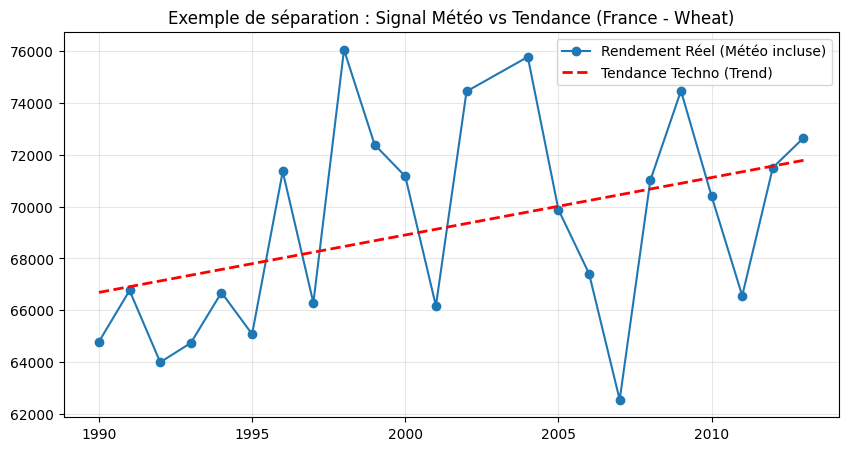

✅ Feature 'yield_trend' calculée et ajoutée.


,Area,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes,span_years,Aridity_Index,yield_trend
0,Albania,Maize,1990,36613.0,1485.0,16.37,121.0,23,56.313993,22238.460827
1,Albania,Maize,1991,29068.0,1485.0,15.36,121.0,23,58.556782,24024.793150
2,Albania,Maize,1992,24876.0,1485.0,16.06,121.0,23,56.983883,25811.125474
3,Albania,Maize,1993,24185.0,1485.0,16.05,121.0,23,57.005758,27597.457797
4,Albania,Maize,1994,25848.0,1485.0,16.96,201.0,23,55.081602,29383.790120


In [13]:
# 1. Préparation de la structure pour stocker les résultats
# On va créer un dictionnaire pour stocker les modèles ou les pentes si besoin,
# mais ici on veut surtout injecter la colonne 'yield_trend' dans le dataframe.

def calculate_trend(group):
    # On prépare X (Année) et y (Rendement)
    X = group[['Year']].values
    y = group['yield_hg_per_ha'].values
    
    # On fit la régression linéaire sur ce groupe spécifique (Pays/Culture)
    model = LinearRegression()
    model.fit(X, y)
    
    # On prédit la tendance sur les années existantes
    # Ce sont les points alignés sur la droite "théorique"
    group['yield_trend'] = model.predict(X)
    
    return group

# 2. Application de la fonction par groupe (Pays + Culture)
# Cela peut prendre quelques secondes
print("⏳ Calcul des tendances technologiques (Linear Regression) par pays/culture...")
df_fao_consolidated = df_fao_consolidated.groupby(['Area', 'Item'], group_keys=False).apply(calculate_trend)

# 3. Vérification visuelle
# On reprend un pays au hasard (ex: France, Blé) pour voir la différence Réel vs Trend
subset = df_fao_consolidated[(df_fao_consolidated['Area'] == 'France') & 
                             (df_fao_consolidated['Item'] == 'Wheat')]

if not subset.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(subset['Year'], subset['yield_hg_per_ha'], label='Rendement Réel (Météo incluse)', marker='o')
    plt.plot(subset['Year'], subset['yield_trend'], label='Tendance Techno (Trend)', linestyle='--', color='red', linewidth=2)
    plt.title("Exemple de séparation : Signal Météo vs Tendance (France - Wheat)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("✅ Feature 'yield_trend' calculée et ajoutée.")
df_fao_consolidated.head()

**Interprétation du visuel (Exemple France/Blé) :**
Ce graphique illustre la logique de notre architecture hybride :
* 🔴 **La Ligne Rouge (`yield_trend`) :** Représente le potentiel théorique du pays. Elle capture l'évolution des infrastructures et du savoir-faire agricole. C'est une information que le climat ne peut pas expliquer.
* 🔵 **La Courbe Bleue (`yield_tonnes_ha`) :** C'est la réalité terrain. On voit clairement que certaines années (ex: 2007), la réalité décroche brutalement sous la ligne rouge.

**Conclusion pour la Modélisation :**
La distance verticale entre la ligne rouge et le point bleu est **l'impact net de la météo** (et des nuisibles).
C'est précisément cette "delta" que notre modèle devra apprendre à prédire en utilisant les features de pluie et de température. Sans cette feature `yield_trend`, le modèle aurait été aveugle au contexte technologique du pays.

## Architecture "Coupling" - Le Modèle "Teacher"

In [14]:
df_fao_consolidated.columns

Index(['Area', 'Item', 'Year', 'yield_hg_per_ha',
       'average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes',
       'span_years', 'Aridity_Index', 'yield_trend'],
      dtype='object')

In [15]:
# ==============================================================================
# 1. DÉFINITION DE LA CONNAISSANCE MÉTIER (PARAMÈTRES FAO)
# ==============================================================================
# Dictionnaire des besoins physiologiques par culture
# Sources : FAO Water (Crop Water Information) & ECOCROP
# - rain_opt_min/max : Plage de précipitation optimale (mm/an)
# - temp_opt_min/max : Plage de température optimale (°C)
# - temp_crit_high : Seuil de stress thermique sévère (échaudage)

CROP_PARAMS = {
    'Wheat':      {'rain_opt': 550,  'temp_opt_min': 15, 'temp_opt_max': 25, 'temp_crit': 30},
    'Maize':      {'rain_opt': 650,  'temp_opt_min': 20, 'temp_opt_max': 30, 'temp_crit': 35},
    'Rice':       {'rain_opt': 1000, 'temp_opt_min': 22, 'temp_opt_max': 32, 'temp_crit': 36},
    'Soybean':   {'rain_opt': 500,  'temp_opt_min': 20, 'temp_opt_max': 30, 'temp_crit': 35}
}

# ==============================================================================
# 2. LE MOTEUR AGRONOMIQUE
# ==============================================================================

def calculate_agronomic_stress(row):
    
    """Calcule les indices de stress basés sur la culture et le climat local.
    Compatible avec les colonnes Teacher (Rainfall_mm) et Student (Rain_Cycle)."""
    
    # 1. Gestion des noms de colonnes (Harmonisation)
    # On cherche 'Crop' (Teacher) ou 'Item' (Student)
    crop = row.get('Crop', row.get('Item')) 
    
    # On cherche 'Rainfall_mm' (Teacher) ou 'Rain_Cycle' (Student)
    rain = row.get('Rainfall_mm', row.get('average_rain_fall_mm_per_year'))
    
    # On cherche 'Temperature_Celsius' (Teacher) ou 'Temp_Cycle' (Student)
    temp = row.get('Temperature_Celsius', row.get('avg_temp'))
    
    # Sécurité : Si une donnée manque, on renvoie NaN ou 0
    if pd.isna(rain) or pd.isna(temp):
        return pd.Series([np.nan, np.nan], index=['Water_Stress', 'Heat_Stress'])

    # 2. Récupération des paramètres de la culture
    params = CROP_PARAMS.get(crop)
    
    # --- A. CALCUL DU STRESS HYDRIQUE (Water Stress) ---
    # Formule : Écart relatif à l'optimum
    
    delta_rain = rain - params['rain_opt']
    
    if delta_rain < 0:
        # Manque d'eau (Sécheresse)
        w_stress = abs(delta_rain) / params['rain_opt']
    else:
        # Trop d'eau (Asphyxie racinaire) - Impact réduit de moitié (0.5)
        w_stress = (delta_rain / params['rain_opt']) * 0.5
        
    # Cap à 1.0
    w_stress = min(w_stress, 1.0)

    # --- B. CALCUL DU STRESS THERMIQUE (Heat Stress) ---
    h_stress = 0.0
    
    # Trop froid
    if temp < params['temp_opt_min']:
        h_stress = (params['temp_opt_min'] - temp) / 10 
        
    # Trop chaud (Stress modéré)
    elif temp > params['temp_opt_max']:
        h_stress = (temp - params['temp_opt_max']) / 10
        
        # Trop chaud (Stress Critique / Echaudage)
        if temp > params['temp_crit']:
            h_stress *= 2.0 # Pénalité doublée
            
    # Cap à 1.0
    h_stress = min(h_stress, 1.0)
    
    return pd.Series([w_stress, h_stress], index=['Water_Stress', 'Heat_Stress'])
    
# ==============================================================================
# 3. APPLICATION SUR LE DATASET FAO
# ==============================================================================
print("🚜 Démarrage du Moteur Agronomique (Modèle Biophysique)...")

# Application de la fonction directement sur df_fao_consolidated
stress_cols = df_fao_consolidated.apply(calculate_agronomic_stress, axis=1)

# On concatène ces nouvelles colonnes directement au dataset principal
df_fao_consolidated = pd.concat([df_fao_consolidated, stress_cols], axis=1)

# Contrôle visuel des nouvelles features
df_fao_consolidated[['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'avg_temp', 'Water_Stress', 'Heat_Stress']].head()

🚜 Démarrage du Moteur Agronomique (Modèle Biophysique)...


,Area,Item,Year,average_rain_fall_mm_per_year,avg_temp,Water_Stress,Heat_Stress
0,Albania,Maize,1990,1485.0,16.37,0.642308,0.363
1,Albania,Maize,1991,1485.0,15.36,0.642308,0.464
2,Albania,Maize,1992,1485.0,16.06,0.642308,0.394
3,Albania,Maize,1993,1485.0,16.05,0.642308,0.395
4,Albania,Maize,1994,1485.0,16.96,0.642308,0.304


## Rétro-Ingénierie sur le Simulateur (Extraction des Règles)

### Encodage des variables catégorielles

In [16]:
# On liste toutes les colonnes textuelles à encoder
cols_to_encode = ['Soil_Type', 'Region', 'Crop', 'Weather_Condition']

# Pandas va créer les colonnes binaires pour toutes ces variables d'un seul coup
df_dummy_synthetique = pd.get_dummies(df_dummy_synthetique, columns=cols_to_encode, dtype=int)

# Affichage pour vérifier
display(df_dummy_synthetique.head())

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,...,Region_North,Region_South,Region_West,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny
0,992.673282,18.026142,1,1,140,8.527341,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
1,986.866331,16.644190,0,1,146,6.517573,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0
2,730.379174,31.620687,1,1,110,7.248251,0,0,0,0,...,0,1,0,0,0,0,1,1,0,0
3,797.471182,37.704974,0,1,74,5.898416,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
4,357.902357,31.593431,0,0,90,2.652392,0,1,0,0,...,0,0,1,0,0,0,1,0,1,0


In [17]:
df_dummy_synthetique.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,...,Region_North,Region_South,Region_West,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny
0,992.673282,18.026142,1,1,140,8.527341,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
1,986.866331,16.644190,0,1,146,6.517573,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0
2,730.379174,31.620687,1,1,110,7.248251,0,0,0,0,...,0,1,0,0,0,0,1,1,0,0
3,797.471182,37.704974,0,1,74,5.898416,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
4,357.902357,31.593431,0,0,90,2.652392,0,1,0,0,...,0,0,1,0,0,0,1,0,1,0


### Régression linéaire

In [18]:
# Préparation X et y
X = df_dummy_synthetique.loc[:, df_dummy_synthetique.columns != 'Yield_tons_per_hectare']
y = df_dummy_synthetique['Yield_tons_per_hectare']

# Régression linéaire
model = LinearRegression()
model.fit(X, y)

# Calcul de la performance (Prédiction sur X lui-même !)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"🎯 Score R2 de la rétro-ingénierie : {r2:.4f}")

🎯 Score R2 de la rétro-ingénierie : 0.9130


### Extraction des coefficients

In [19]:
df_rules = pd.DataFrame(zip(X.columns, model.coef_), columns=['Variable', 'Coef'])
df_rules = df_rules.sort_values(by=['Coef'], ascending=False)

In [20]:
df_rules.head()

,Variable,Coef
2,Fertilizer_Used,1.500097
3,Irrigation_Used,1.199605
1,Temperature_Celsius,0.019822
0,Rainfall_mm,0.004997
16,Crop_Rice,0.002175


> **Interprétation : Les règles maîtresses du simulateur**
> Notre rétro-ingénierie révèle immédiatement la logique simpliste du dataset synthétique : il a codé des règles additives fixes et massives pour les pratiques agricoles. Dans son équation, l'utilisation d'engrais octroie un bonus direct de **+1.5 tonne/ha**, et l'irrigation ajoute **+1.2 tonne/ha**.

In [21]:
df_rules[df_rules['Variable'].str.contains('Soil')]

,Variable,Coef
6,Soil_Type_Clay,0.001991
8,Soil_Type_Peaty,0.000459
5,Soil_Type_Chalky,0.000222
9,Soil_Type_Sandy,0.000036
7,Soil_Type_Loam,-0.000591
10,Soil_Type_Silt,-0.002118


> **💡 Interprétation : Les règles cachées des Sols**
> Contrairement aux pratiques agricoles, le développeur a attribué un impact mathématique minuscule à la nature du sol (de l'ordre de quelques kilos par hectare). Néanmoins, la hiérarchie est désormais exposée : l'Argile (*Clay*) est le sol le plus favorable de ce simulateur, tandis que le Limon (*Silt*) agit comme un léger malus.

In [22]:
# Saugarde dans un dictionnaire
# 1. Transformation en dictionnaire "plat"
rules_dict = df_rules.set_index('Variable')['Coef'].to_dict()

# Vérification
print(rules_dict)

{'Fertilizer_Used': 1.5000971871306785, 'Irrigation_Used': 1.1996045538078512, 'Temperature_Celsius': 0.019821573468626435, 'Rainfall_mm': 0.004997483597538351, 'Crop_Rice': 0.0021754698390494993, 'Soil_Type_Clay': 0.001991083794358293, 'Weather_Condition_Rainy': 0.0019568834973216517, 'Region_East': 0.0007324605589777689, 'Region_North': 0.0007321168285687283, 'Crop_Soybean': 0.0007153412663255592, 'Soil_Type_Peaty': 0.00045949605875574484, 'Soil_Type_Chalky': 0.00022206369936563167, 'Soil_Type_Sandy': 3.640417617366595e-05, 'Days_to_Harvest': 3.0215993189601963e-05, 'Weather_Condition_Cloudy': -0.0004937260557980369, 'Region_West': -0.0005256785000572681, 'Soil_Type_Loam': -0.0005908911612027777, 'Region_South': -0.000938898887489147, 'Crop_Wheat': -0.0013275672699653964, 'Weather_Condition_Sunny': -0.001463157441523388, 'Crop_Maize': -0.0015632438354093439, 'Soil_Type_Silt': -0.0021181565674507365}


In [23]:
# Saugarde
DONNEES_PROCESSED.mkdir(parents=True, exist_ok=True)

# 2. Construction dynamique du chemin de sauvegarde
chemin_fichier_json = DONNEES_PROCESSED / 'business_rules.json'

# 3. Sauvegarde propre du dictionnaire
# (L'ajout de encoding='utf-8' garantit une lecture sans bug sous Streamlit)
with open(chemin_fichier_json, 'w', encoding='utf-8') as f:
    json.dump(rules_dict, f, indent=4)

print(f"✅ Artefact sauvegardé avec succès dans : {chemin_fichier_json}")

✅ Artefact sauvegardé avec succès dans : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\data\processed\business_rules.json


## Création de la table de référence

In [24]:
# 1. Agrégation par Pays et Culture (Moyenne historique)
df_climate_ref = df_fao_consolidated.groupby(['Area', 'Item'])[['average_rain_fall_mm_per_year', 'avg_temp']].mean().reset_index()

# 2. Nettoyage visuel pour l'UI (On arrondit les valeurs)
df_climate_ref['average_rain_fall_mm_per_year'] = df_climate_ref['average_rain_fall_mm_per_year'].round(0)
df_climate_ref['avg_temp'] = df_climate_ref['avg_temp'].round(1)

# 3. Sauvegarde MLOps
chemin_ref_climatique = DONNEES_PROCESSED / 'climate_reference.csv'
df_climate_ref.to_csv(chemin_ref_climatique, index=False, encoding='utf-8')

print(f"✅ Table de référence sauvegardée dans : {chemin_ref_climatique}")

# Aperçu du livrable
display(df_climate_ref.head())

✅ Table de référence sauvegardée dans : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\data\processed\climate_reference.csv


,Area,Item,average_rain_fall_mm_per_year,avg_temp
0,Albania,Maize,1485.0,16.3
1,Albania,Soybean,1485.0,16.3
2,Albania,Wheat,1485.0,16.3
3,Algeria,Maize,89.0,17.5
4,Algeria,Rice,89.0,17.5


## Sauvegarde

In [25]:
# On définit un nouveau nom pour marquer la fin de l'étape de Feature Engineering
filename_engineered = "df_fao_engineered.csv"

# Construction dynamique du chemin
chemin_fao_engineered = DONNEES_PROCESSED / filename_engineered

# Sauvegarde propre (avec encoding utf-8 pour éviter tout bug de lecture)
df_fao_consolidated.to_csv(chemin_fao_engineered, index=False, encoding='utf-8')

print(f"🎉 Félicitations ! Golden Dataset enrichi exporté avec succès dans : {chemin_fao_engineered}")
print(f"Dimensions finales : {df_fao_consolidated.shape}")

🎉 Félicitations ! Golden Dataset enrichi exporté avec succès dans : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\data\processed\df_fao_engineered.csv
Dimensions finales : (6492, 12)
